In [65]:
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import interp1d
# Load data from CSV file

def make_plot_for_country_hparam_comparison(country, metric):

    train_data = pd.read_parquet("../data/{}/train.parquet".format(country))
    n_train = len(train_data)
    test_data = pd.read_parquet("../data/{}/test.parquet".format(country))
    n_test = len(test_data)
    n= n_train + n_test
    d = len(train_data.columns)

    methods = {'continuous_gap': {'name': 'Poverty Gap Targeting (Continuous-Valued)'},
            'binary_gap': { 'name': 'Poverty Gap Targeting (Binary-Valued)'},
            'continuous_rate': {'name': 'Poverty Rate Targeting (Continuous-Valued)'},
            'binary_rate': {'name': 'Poverty Rate Targeting (Binary-Valued)'},
            }
    if metric == 'post_transfer_poverty_rate':
        del methods['continuous_gap']
        del methods['binary_gap']
    elif metric == 'post_transfer_poverty_gap':
        del methods['continuous_rate']
        del methods['binary_rate']
    
    conversion_factor = 1.0

    for method in methods:
        dic = methods[method]
        print(dic)
        dic['gt_df'] = pd.read_csv('results/{}/output_gt_{}.csv'.format(country, method))
        dic['default_df'] = pd.read_csv('results/{}/default_{}.csv'.format(country, method))

    fontsize = 20

    # Plot policy_cost_per_capita vs post_transfer_poverty_rate
    fig, ax = plt.subplots(1, 2, figsize=(20, 8))

    for i in range(2):
        method_idx = i
        method = list(methods.keys())[method_idx]
        dic = methods[method]
        gt_df = dic['gt_df']
        default_df = dic['default_df']
        ax[i].plot(gt_df[metric], gt_df['policy_cost_per_capita'] * conversion_factor, marker='o', label="GT HParam")
        ax[i].plot(default_df[metric], default_df['policy_cost_per_capita'] * conversion_factor, marker='o', label='Default HParam')
        ax[i].set_xlabel(metric, fontsize=fontsize)        
        ax[i].set_title('{}: Policy Cost vs {}'.format(method, metric), fontsize=fontsize)

        ax[i].legend(fontsize=fontsize)
        ax[i].set_ylabel('Policy Cost', fontsize=fontsize)
        ax[i].grid(True)
        ax[i].tick_params(axis='x', labelsize=15)  
        ax[i].tick_params(axis='y', labelsize=15)


    plt.suptitle('{} (n={}, d={}): Policy Cost vs. {} - HParam Comparison'.format(country, n, d, metric), fontsize=fontsize + 2)
    plt.tight_layout()
    plt.savefig('figs/{}_policy_cost_vs_{}_hparam.pdf'.format(country, metric))


{'name': 'Poverty Gap Targeting (Continuous-Valued)'}
{'name': 'Poverty Gap Targeting (Binary-Valued)'}


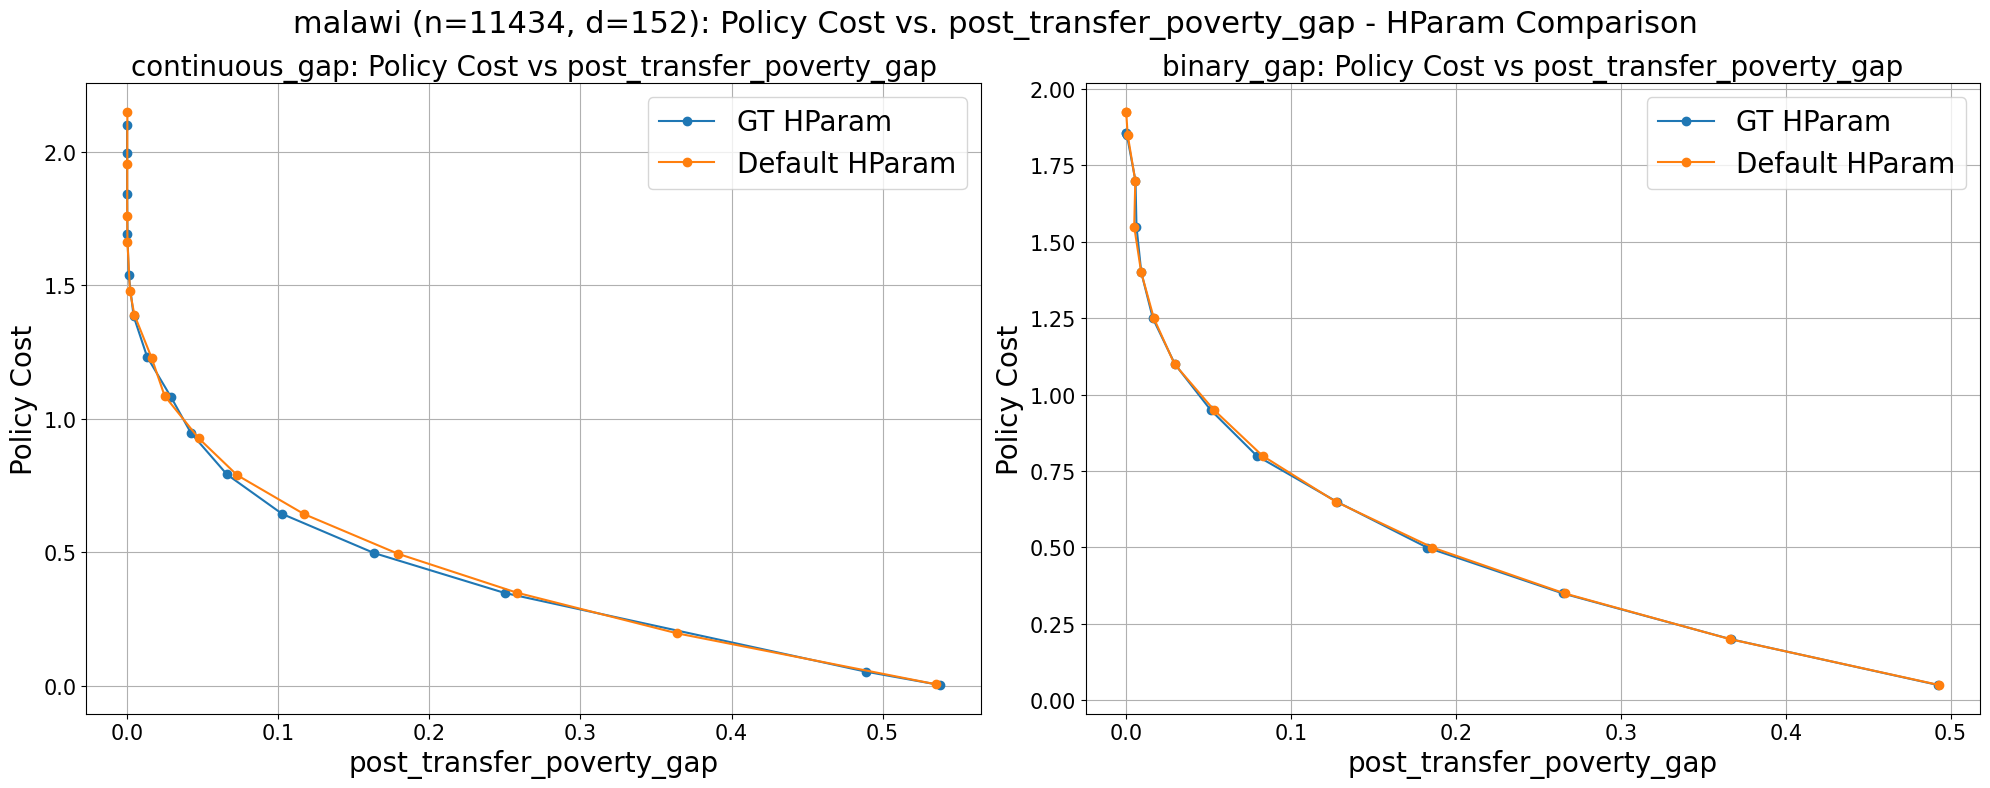

In [66]:
make_plot_for_country_hparam_comparison('malawi', 'post_transfer_poverty_gap')

{'name': 'Poverty Gap Targeting (Continuous-Valued)'}
{'name': 'Poverty Gap Targeting (Binary-Valued)'}


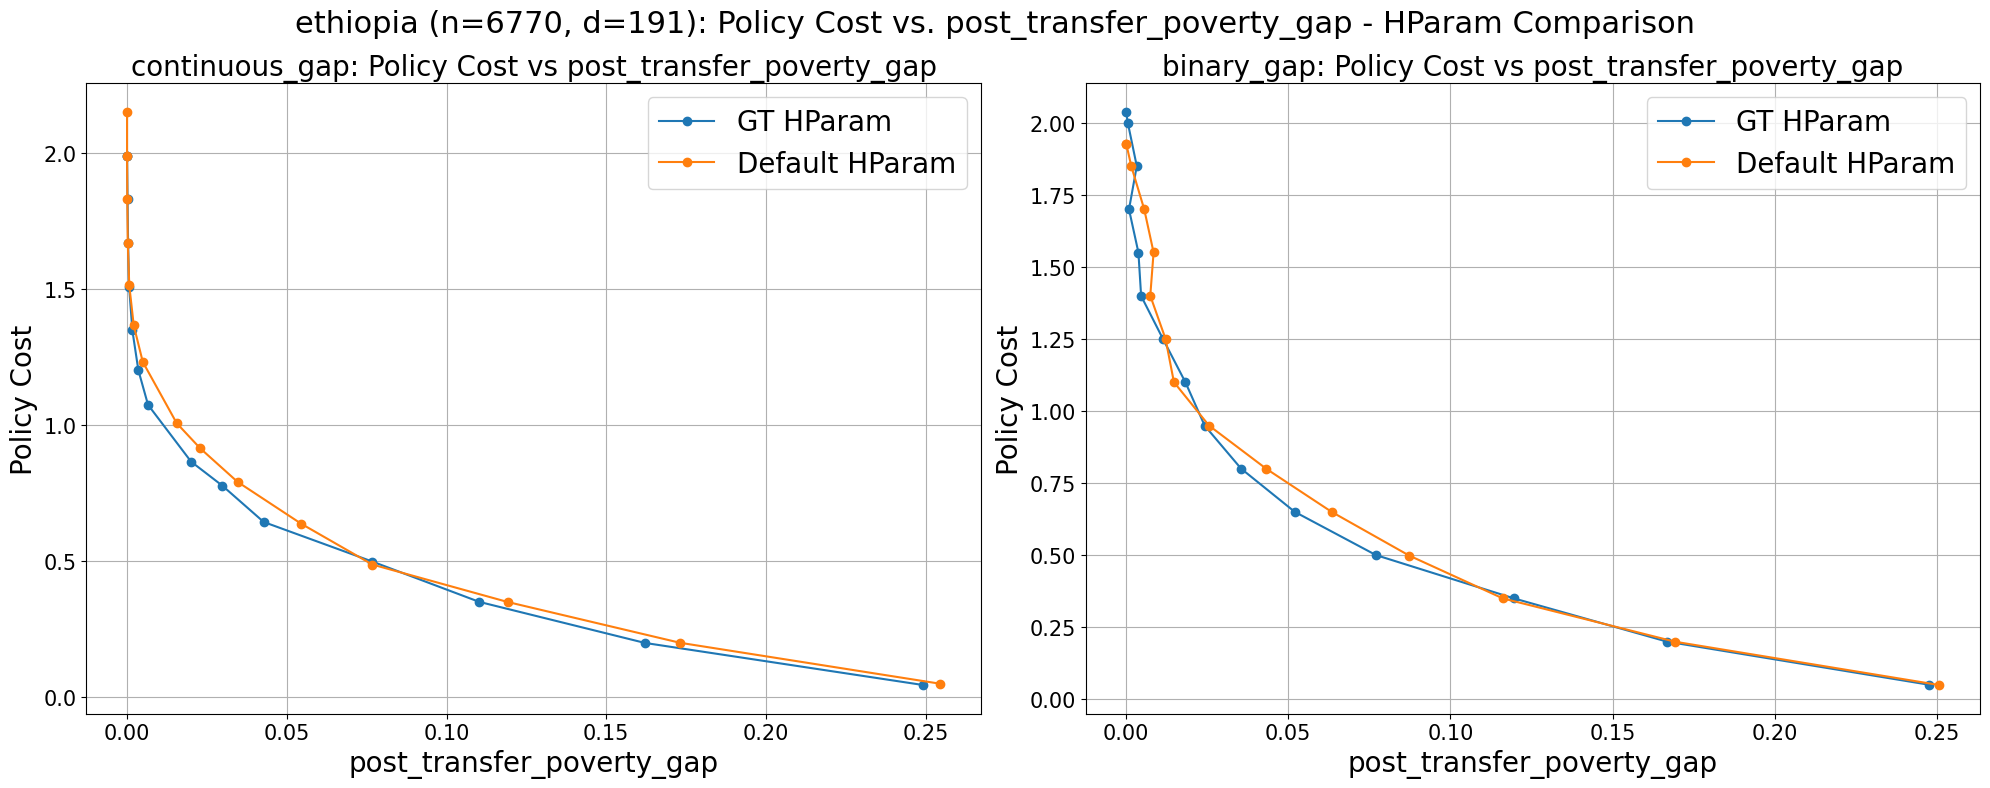

In [67]:
make_plot_for_country_hparam_comparison("ethiopia", "post_transfer_poverty_gap")

{'name': 'Poverty Gap Targeting (Continuous-Valued)'}
{'name': 'Poverty Gap Targeting (Binary-Valued)'}


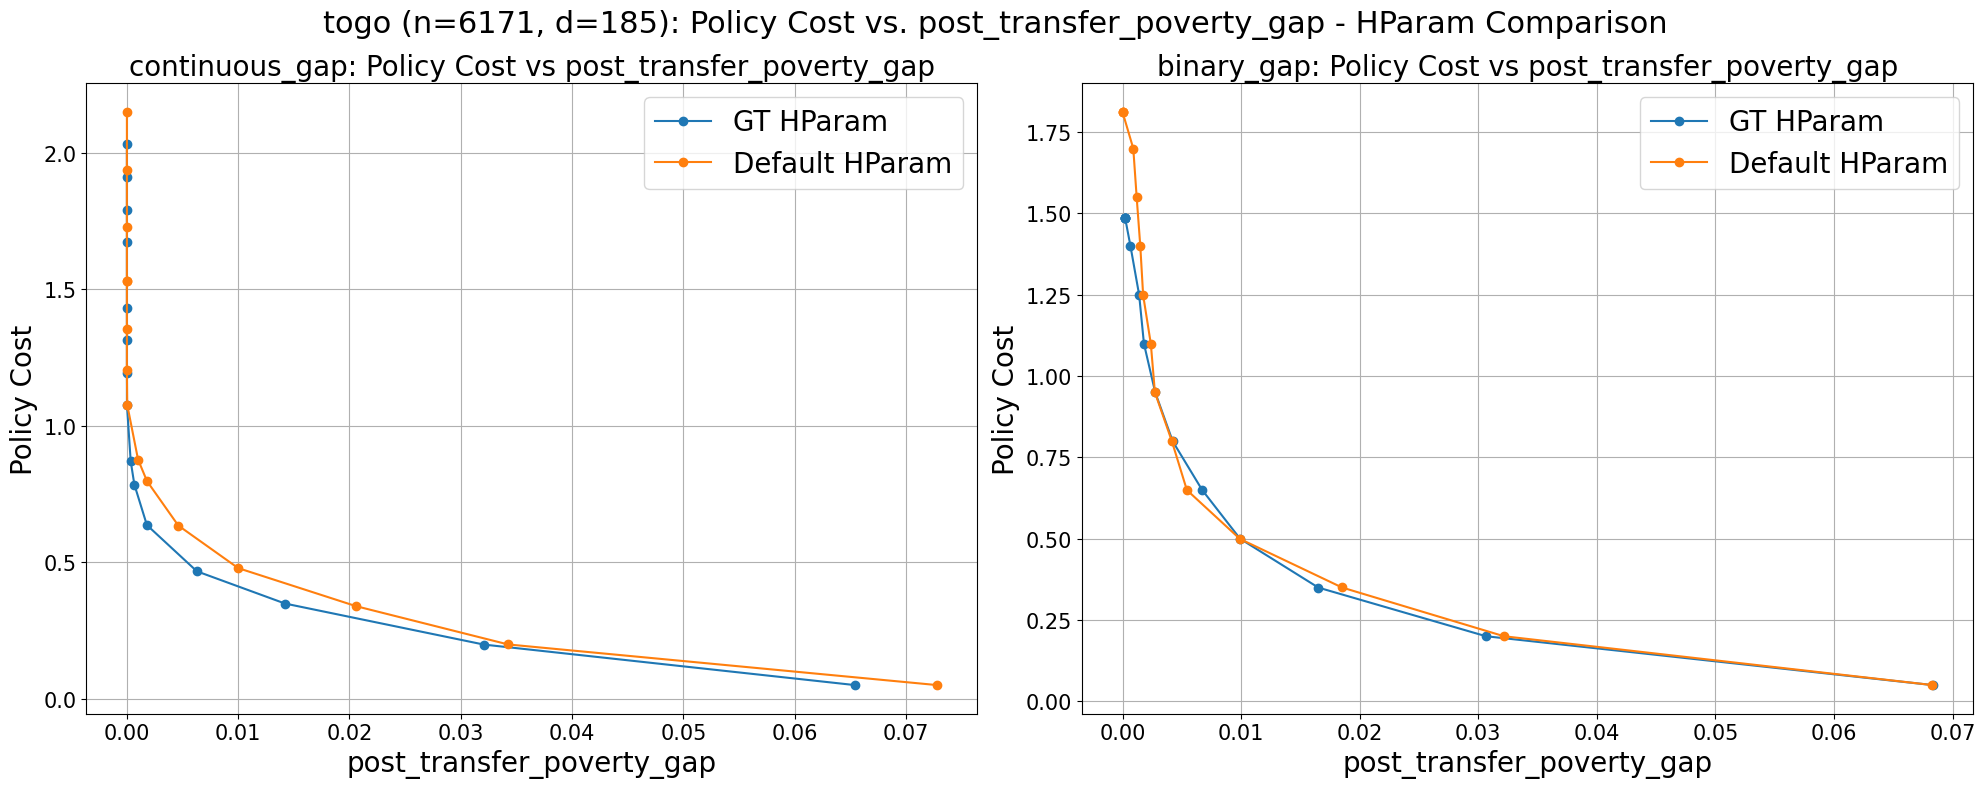

In [68]:
make_plot_for_country_hparam_comparison("togo", "post_transfer_poverty_gap")